In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
# BUGFIX: Do not force PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION="python".
# In this Kaggle environment (protobuf 6.x + TF 2.18), forcing the python
# implementation can trigger: AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
# We rely on the default (cpp) implementation shipped with the runtime.
os.environ.pop("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", None)

import warnings

warnings.filterwarnings("ignore")

import re, random, time, zipfile, gc, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import RMSprop, Adam

import cv2

print("TF:", tf.__version__)
print("Keras:", keras.__version__)



2026-01-15 19:41:53.246737: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768506113.260740      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768506113.264828      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TF: 2.18.0
Keras: 3.8.0


In [2]:
PATH = "/kaggle/input/dogs-vs-cats-redux-kernels-edition/"
train_zip_path = os.path.join(PATH, "train.zip")
test_zip_path = os.path.join(PATH, "test.zip")

WORK_DATA_DIR = "/kaggle/working/data"
os.makedirs(WORK_DATA_DIR, exist_ok=True)


def maybe_extract(zip_path, out_dir):
    """Extract zip into out_dir unless it looks already extracted."""
    marker = os.path.join(
        out_dir, f".extracted_{os.path.splitext(os.path.basename(zip_path))[0]}"
    )
    if os.path.exists(marker):
        return
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    with open(marker, "w") as f:
        f.write("ok")


maybe_extract(train_zip_path, WORK_DATA_DIR)
maybe_extract(test_zip_path, WORK_DATA_DIR)

print("WORK_DATA_DIR listing (top-level):", sorted(os.listdir(WORK_DATA_DIR))[:50])



WORK_DATA_DIR listing (top-level): ['.extracted_test', '.extracted_train', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg', '1005.jpg', '1006.jpg', '1007.jpg', '1008.jpg', '1009.jpg', '101.jpg', '1010.jpg', '1011.jpg', '1012.jpg', '1013.jpg', '1014.jpg', '1015.jpg', '1016.jpg', '1017.jpg', '1018.jpg', '1019.jpg', '102.jpg', '1020.jpg', '1021.jpg', '1022.jpg', '1023.jpg', '1024.jpg', '1025.jpg', '1026.jpg', '1027.jpg', '1028.jpg', '1029.jpg', '103.jpg', '1030.jpg', '1031.jpg', '1032.jpg', '1033.jpg', '1034.jpg', '1035.jpg', '1036.jpg', '1037.jpg', '1038.jpg', '1039.jpg', '104.jpg', '1040.jpg']


In [3]:
start = time.time()


def find_dir_with_images(root, exts=(".jpg", ".jpeg", ".png")):
    """Find a directory under 'root' that contains the most images."""
    candidates = []
    for dirpath, _, filenames in os.walk(root):
        img_count = sum(fn.lower().endswith(exts) for fn in filenames)
        if img_count > 0:
            candidates.append((img_count, dirpath))
    if not candidates:
        return None
    candidates.sort(reverse=True)  # most images first
    return candidates[0][1]


def list_images_flat(root, exts=(".jpg", ".jpeg", ".png")):
    paths = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.lower().endswith(exts):
                paths.append(os.path.join(dirpath, fn))
    return paths


# BUGFIX: zips extract into WORK_DATA_DIR with their own internal structure,
# so infer actual train/test roots from WORK_DATA_DIR after extraction.
train_root = find_dir_with_images(WORK_DATA_DIR)
test_root = find_dir_with_images(WORK_DATA_DIR)

if train_root is None or test_root is None:
    raise FileNotFoundError(
        f"Could not locate extracted image folders under {WORK_DATA_DIR}. "
        f"train_root={train_root}, test_root={test_root}"
    )

# Heuristic refinement: train files are usually named cat.xxx.jpg/dog.xxx.jpg; test files are numeric.
all_image_paths = list_images_flat(WORK_DATA_DIR)
train_like = [
    p
    for p in all_image_paths
    if re.match(r"^(cat|dog)\.\d+\.(jpg|jpeg|png)$", os.path.basename(p).lower())
]
test_like = [
    p
    for p in all_image_paths
    if re.match(r"^\d+\.(jpg|jpeg|png)$", os.path.basename(p).lower())
]

# Prefer these refined lists when available.
train_images = train_like if len(train_like) > 0 else list_images_flat(train_root)
test_images = test_like if len(test_like) > 0 else list_images_flat(test_root)

print("Detected train images:", len(train_images))
print("Detected test images:", len(test_images))
print("Sample train file:", os.path.basename(train_images[0]) if train_images else None)
print("Sample test file:", os.path.basename(test_images[0]) if test_images else None)




Detected train images: 22500
Detected test images: 2500
Sample train file: dog.7296.jpg
Sample test file: 316.jpg


In [4]:
def txt_dig(text):
    return int(text) if text.isdigit() else text


def natural_keys(text):
    return [txt_dig(c) for c in re.split(r"(\d+)", text)]


def extract_id_from_path(p):
    base = os.path.basename(p)
    m = re.match(r"(\d+)\.", base)
    return int(m.group(1)) if m else None


train_images.sort(key=natural_keys)

test_ids_from_files = [extract_id_from_path(p) for p in test_images]
if len(test_images) > 0 and all(t is not None for t in test_ids_from_files):
    test_images = [
        p for _, p in sorted(zip(test_ids_from_files, test_images), key=lambda x: x[0])
    ]
else:
    test_images.sort(key=natural_keys)

print("First 5 test basenames:", [os.path.basename(p) for p in test_images[:5]])



First 5 test basenames: ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']


In [5]:
# Keep original core logic: use a sampled subset of training images.
n = len(train_images)
part1 = train_images[: min(1300, n)]
part2 = train_images[min(12500, n) : min(13800, n)]
train_images = part1 + part2

print("Using sampled train images:", len(train_images))



Using sampled train images: 2600


In [6]:
IMG_WIDTH = 128
IMG_HEIGHT = 128


def read_and_resize(path, w=128, h=128):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Failed to read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (w, h), interpolation=cv2.INTER_CUBIC)
    return img


x = [read_and_resize(p, IMG_WIDTH, IMG_HEIGHT) for p in train_images]
test = [read_and_resize(p, IMG_WIDTH, IMG_HEIGHT) for p in test_images]

x = np.array(x, dtype=np.uint8)
test = np.array(test, dtype=np.uint8)



In [7]:
print("The shape of train data is {}".format(x.shape))
print("The shape of test data is {}".format(test.shape))



The shape of train data is (2600, 128, 128, 3)
The shape of test data is (2500, 128, 128, 3)


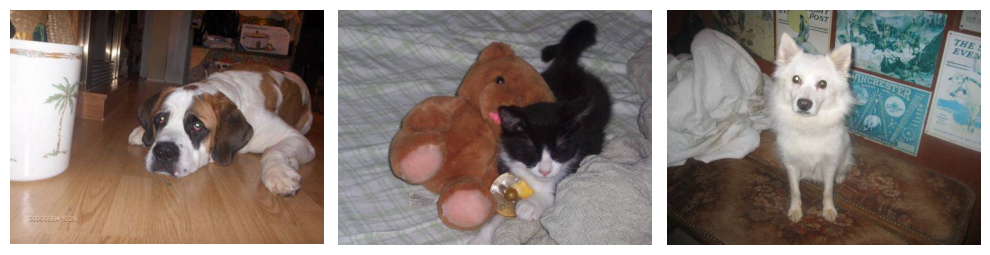

In [8]:
random.seed(558)
plt.rcParams["figure.facecolor"] = "white"
plt.figure(figsize=(10, 4))

for i in range(3):
    sample = random.choice(train_images)
    image = load_img(sample)
    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
plt.tight_layout()
plt.show()



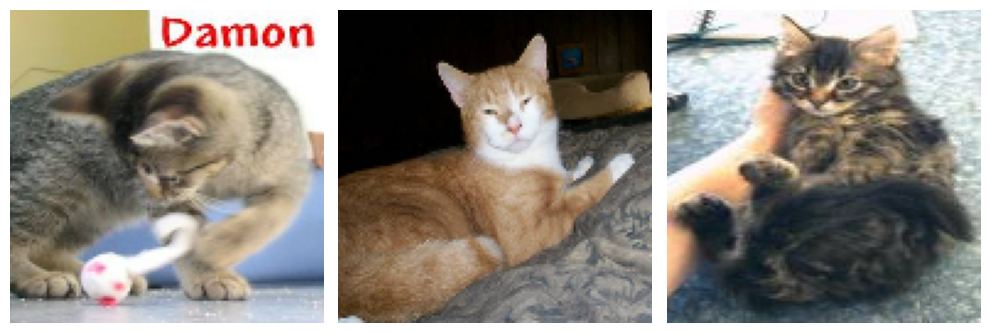

In [9]:
plt.rcParams["figure.facecolor"] = "white"
plt.figure(figsize=(10, 4))
idxs = [0, 1, 2]
idxs = [i for i in idxs if i < len(x)]
for i, idx in enumerate(idxs):
    plt.subplot(1, 3, i + 1)
    plt.imshow(x[idx])
    plt.axis("off")
plt.tight_layout()
plt.show()



In [10]:
y = []
for p in train_images:
    base = os.path.basename(p).lower()
    parts = os.path.normpath(p).lower().split(os.sep)
    if "dog" in parts or base.startswith("dog"):
        y.append(1)
    elif "cat" in parts or base.startswith("cat"):
        y.append(0)
    else:
        raise ValueError(f"Cannot infer label from path: {p}")

y = np.array(y, dtype=np.int32)
print(
    "Num labels:", len(y), "Pos (dog):", int(y.sum()), "Neg (cat):", int((1 - y).sum())
)

x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=2020, stratify=y
)



Num labels: 2600 Pos (dog): 1300 Neg (cat): 1300


In [11]:
model = models.Sequential()

efnModel = tf.keras.applications.EfficientNetB7(
    weights="imagenet", input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), include_top=False
)
model.add(efnModel)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(1, activation="sigmoid"))

opt1 = RMSprop(learning_rate=0.005, decay=1e-6)
opt2 = Adam(learning_rate=0.006)

model.compile(loss="binary_crossentropy", optimizer=opt2, metrics=["accuracy"])
model.summary()



I0000 00:00:1768506128.205027      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38939 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:05:00.0, compute capability: 8.6


258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb7 (Functional)     │ (None, 4, 4, 2560)     │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2560)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,100,248 (244.52 MB)

 Trainable params: 63,789,521 (243.34 MB)

 Non-trainable params: 310,727 (1.19 MB)

In [12]:
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)




Found 1 validated image filenames.


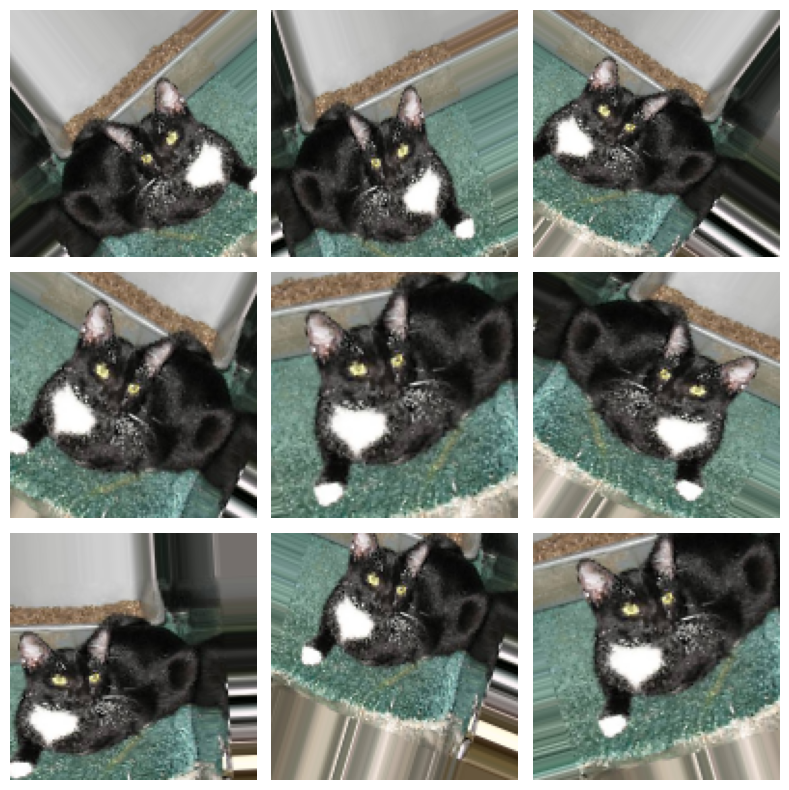

In [13]:
def plot_gened(train_images, seed=320):
    df = pd.DataFrame({"filename": train_images})
    np.random.seed(seed)
    vis_df = df.sample(n=1).reset_index(drop=True)
    vis_df["category"] = "0"
    vis_gen = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode="nearest",
    )
    vis_gen0 = vis_gen.flow_from_dataframe(
        vis_df,
        x_col="filename",
        y_col="category",
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=16,
        class_mode="raw",
        shuffle=False,
    )
    plt.rcParams["figure.facecolor"] = "white"
    plt.figure(figsize=(8, 8))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        X_batch, _ = next(vis_gen0)
        plt.imshow(X_batch[0])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


plot_gened(train_images)



In [14]:
BATCH_SIZE = 16

train_flow = datagen.flow(x_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_flow = val_datagen.flow(x_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

earlystop1 = EarlyStopping(patience=5, restore_best_weights=True)
earlystop2 = ReduceLROnPlateau(
    monitor="val_accuracy", min_lr=0.001, patience=5, mode="max", verbose=1
)

history = model.fit(
    train_flow,
    steps_per_epoch=55,
    epochs=20,
    validation_data=val_flow,
    callbacks=[earlystop1, earlystop2],
    validation_steps=25,
)



Epoch 1/20


I0000 00:00:1768506208.457310      68 service.cc:148] XLA service 0x7f63c8006da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768506208.457343      68 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
I0000 00:00:1768506219.381456      68 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1768506232.204011      68 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1768506232.376411      68 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1768506232.536776      68 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1768506232.708519  

55/55 ━━━━━━━━━━━━━━━━━━━━ 145s 250ms/step - accuracy: 0.5499 - loss: 1.3059 - val_accuracy: 0.4950 - val_loss: 133775384.0000 - learning_rate: 0.0060
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.4940 - loss: 0.7350 - val_accuracy: 0.4950 - val_loss: 153196.7656 - learning_rate: 0.0060
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5028 - loss: 0.7168 - val_accuracy: 0.4950 - val_loss: 5589.4326 - learning_rate: 0.0060
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.5058 - loss: 0.7292 - val_accuracy: 0.5050 - val_loss: 1039.7209 - learning_rate: 0.0060
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.5064 - loss: 0.7025 - val_accuracy: 0.4950 - val_loss: 50.4739 - learning_rate: 0.0060
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5289 - loss: 0.7124 - val_accuracy: 0.5050 - val_loss: 0.7005 - learning_rate: 0.0060
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.5198 - loss: 0.69

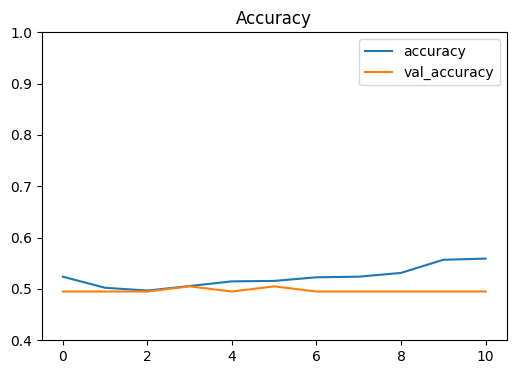

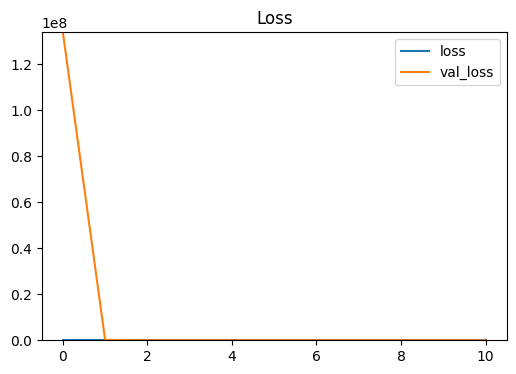

In [15]:
plt.rcParams["figure.facecolor"] = "white"
model_loss = pd.DataFrame(history.history)

ax = model_loss[["accuracy", "val_accuracy"]].plot(ylim=[0.4, 1.0], figsize=(6, 4))
ax.set_title("Accuracy")
plt.show()

ax = model_loss[["loss", "val_loss"]].plot(
    ylim=[0.0, max(1.0, float(model_loss[["loss", "val_loss"]].max().max()))],
    figsize=(6, 4),
)
ax.set_title("Loss")
plt.show()



In [16]:
val_steps = int(np.ceil(len(x_val) / BATCH_SIZE))
val_preds = model.predict(val_flow, verbose=1, steps=val_steps).ravel()
print(val_steps)
print("Out of Fold log loss is {:.5f}".format(log_loss(y_val, val_preds)))



33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 319ms/step
33
Out of Fold log loss is 0.70204


In [17]:
test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_flow = test_datagen.flow(test, batch_size=BATCH_SIZE, shuffle=False)

test_steps = int(np.ceil(len(test) / BATCH_SIZE))
test_pred = model.predict(test_flow, verbose=1, steps=test_steps).ravel()
print(test_steps)



157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step
157


In [18]:
sample_path_candidates = [
    "/kaggle/input/dogs-vs-cats-redux-kernels-edition/sample_submission.csv",
    "/kaggle/input/sample_submission.csv",
]
sample_path = None
for p in sample_path_candidates:
    if os.path.exists(p):
        sample_path = p
        break
if sample_path is None:
    raise FileNotFoundError(
        "Could not find sample_submission.csv in expected input paths."
    )

sample_sub = pd.read_csv(sample_path)
ids_required = sample_sub["id"].astype(int).tolist()

ids_from_files = [extract_id_from_path(p) for p in test_images]
if not (len(test_pred) >= len(ids_from_files)):
    raise RuntimeError(
        f"Prediction length {len(test_pred)} < num test files {len(ids_from_files)}"
    )

pred_map = {
    int(i): float(p)
    for i, p in zip(ids_from_files, test_pred[: len(ids_from_files)])
    if i is not None
}

labels = [pred_map.get(int(i), 0.5) for i in ids_required]
submission = pd.DataFrame({"id": ids_required, "label": labels})
submission.to_csv("submission.csv", index=False)

print("Wrote submission.csv with shape:", submission.shape)
print("This program costs {:.2f} seconds".format(time.time() - start))
print(submission.head())



Wrote submission.csv with shape: (2500, 2)
This program costs 241.97 seconds
   id     label
0   1  0.565016
1   2  0.558612
2   3  0.555389
3   4  0.567507
4   5  0.576472


In [19]:
shutil.rmtree("/kaggle/working/data/", ignore_errors=True)
gc.collect()
print("Cleaned /kaggle/working/data/")

Cleaned /kaggle/working/data/
